# Tugas Praktikum 2 — Preprocessing Data
**Dataset:** House Prices (`train.csv`) — data karakteristik rumah dan harga jualnya (`SalePrice`)

**Tujuan Praktikum:**
1. Mengeksplorasi struktur dan kualitas data (EDA awal)
2. Menangani nilai yang hilang (*missing values*)
3. Menangani data duplikat
4. Mendeteksi dan menangani *outlier*
5. Melakukan transformasi data: *encoding* variabel kategorikal dan normalisasi/standarisasi variabel numerik
6. Menyimpan dataset hasil preprocessing yang siap digunakan untuk analisis/modeling


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', 15)
sns.set_style('whitegrid')


## 2. Load Dataset
Dataset dibaca dari file `train.csv`.

In [2]:
df = pd.read_csv('train.csv')
print(f"Ukuran dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()


Ukuran dataset: 1460 baris, 81 kolom


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,...,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,...,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,...,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,...,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,...,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,...,NaN,0,12,2008,WD,Normal,250000


## 3. Eksplorasi Awal Data (EDA)
Melihat tipe data tiap kolom dan ringkasan statistik untuk memahami karakteristik dataset sebelum melakukan preprocessing.

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
df.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,...,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,...,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,...,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,...,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,...,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,...,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,...,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## 4. Pemeriksaan Missing Value
Menghitung jumlah dan persentase nilai yang hilang pada tiap kolom, lalu memvisualisasikannya agar mudah dilihat kolom mana yang paling banyak kehilangan data.

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
missing_table = missing_table[missing_table['Jumlah Missing'] > 0].sort_values('Jumlah Missing', ascending=False)
print(f"Total kolom dengan missing value: {len(missing_table)} dari {df.shape[1]} kolom")
missing_table


Total kolom dengan missing value: 19 dari 81 kolom


,Jumlah Missing,Persentase (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


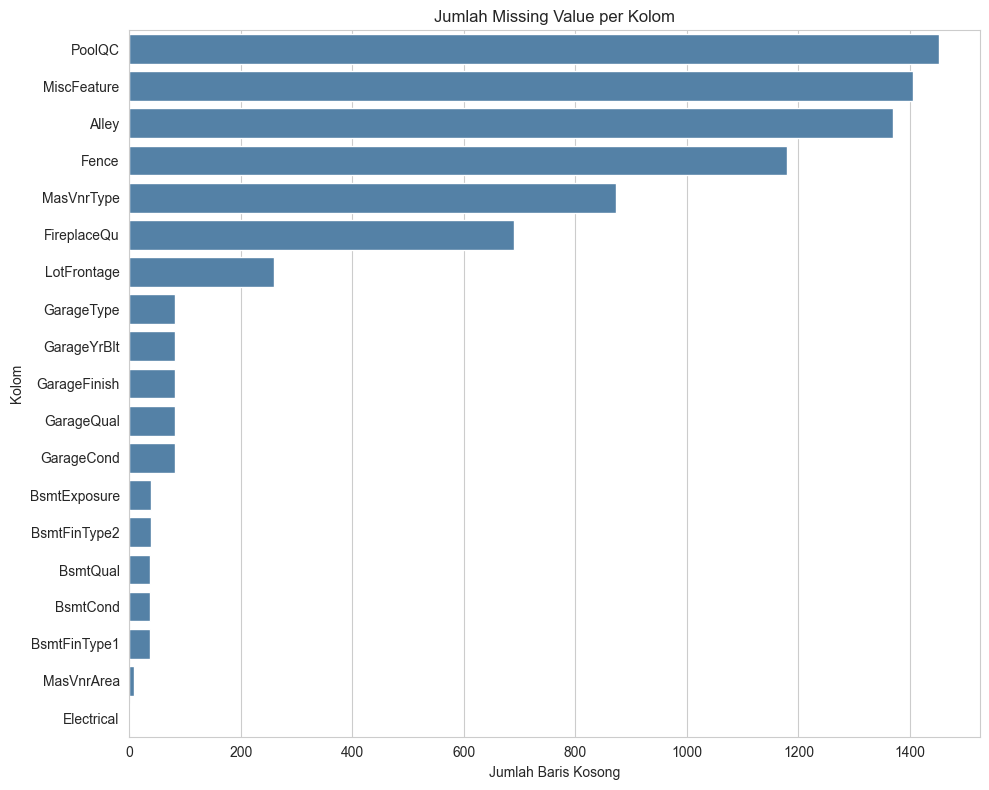

In [6]:
plt.figure(figsize=(10, 8))
sns.barplot(x=missing_table['Jumlah Missing'], y=missing_table.index, color='steelblue')
plt.title('Jumlah Missing Value per Kolom')
plt.xlabel('Jumlah Baris Kosong')
plt.ylabel('Kolom')
plt.tight_layout()
plt.show()


## 5. Penanganan Missing Value

Strategi penanganan dibedakan berdasarkan **makna** nilai kosong pada masing-masing kolom (mengacu pada data dictionary dataset House Prices):

1. **Kolom kategorikal di mana NA memang berarti "fitur tersebut tidak ada"** (mis. `PoolQC` = tidak ada kolam renang, `Alley` = tidak ada akses gang, `GarageType` = tidak ada garasi, dsb) → diisi dengan label `'None'`.
2. **Kolom numerik terkait fitur yang tidak ada** (`GarageYrBlt`, `MasVnrArea`) → diisi dengan `0`.
3. **`LotFrontage`** (panjang sisi lot yang menghadap jalan) → nilainya benar-benar hilang (bukan "tidak ada"), sehingga diisi dengan **median per lingkungan (`Neighborhood`)** karena luas lot sangat dipengaruhi oleh lokasi/lingkungan rumah.
4. **`Electrical`** → hanya 1 baris kosong, diisi dengan **modus** (nilai yang paling sering muncul).


In [7]:
# 1. Kolom kategorikal: NA berarti fitur tidak ada -> isi dengan 'None'
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    df[col] = df[col].fillna('None')

# 2. Kolom numerik: NA berarti fitur tidak ada -> isi dengan 0
zero_cols = ['GarageYrBlt', 'MasVnrArea']
for col in zero_cols:
    df[col] = df[col].fillna(0)

# 3. LotFrontage -> median per Neighborhood
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())  # fallback jika masih ada NA

# 4. Electrical -> modus
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

print("Sisa total missing value setelah penanganan:", df.isnull().sum().sum())


Sisa total missing value setelah penanganan: 0


## 6. Pemeriksaan Data Duplikat

In [8]:
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat: {jumlah_duplikat}")
if jumlah_duplikat > 0:
    df = df.drop_duplicates()
    print("Baris duplikat telah dihapus.")
else:
    print("Tidak ditemukan baris duplikat pada dataset.")


Jumlah baris duplikat: 0
Tidak ditemukan baris duplikat pada dataset.


## 7. Deteksi Outlier
Outlier dideteksi secara visual menggunakan *boxplot* pada beberapa variabel numerik penting, serta secara statistik menggunakan metode **IQR (Interquartile Range)**.

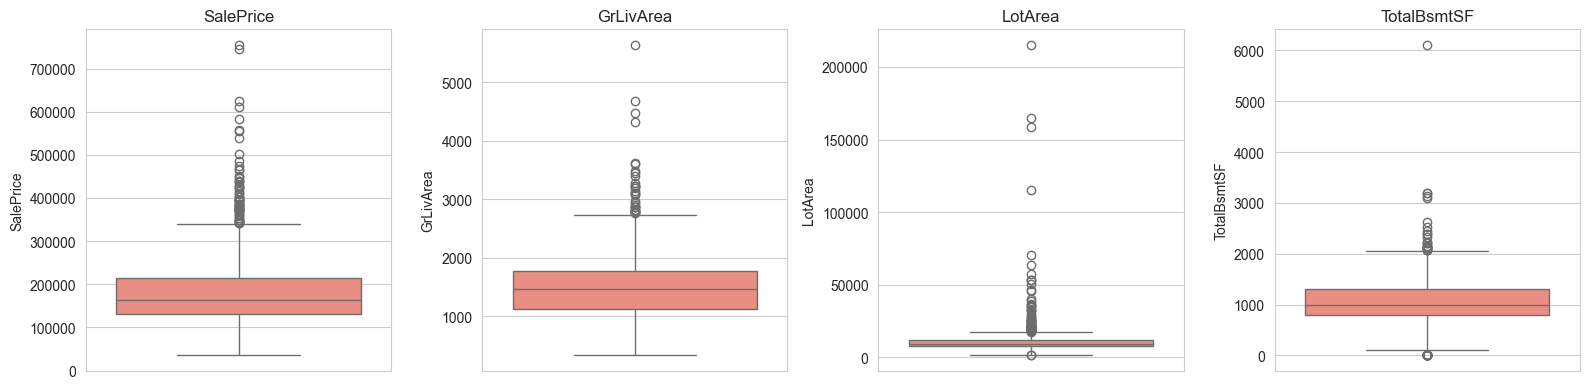

In [9]:
fitur_cek_outlier = ['SalePrice', 'GrLivArea', 'LotArea', 'TotalBsmtSF']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, fitur_cek_outlier):
    sns.boxplot(y=df[col], ax=ax, color='salmon')
    ax.set_title(col)
plt.tight_layout()
plt.show()


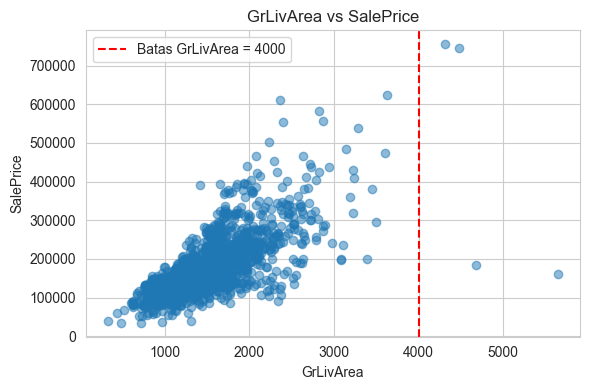

In [10]:
# Scatter plot GrLivArea vs SalePrice -> dokumentasi dataset House Prices
# secara eksplisit menyebut ada beberapa rumah dengan GrLivArea sangat besar
# namun harga jual rendah -> anomali/outlier yang perlu dihapus.
plt.figure(figsize=(6, 4))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5)
plt.axvline(4000, color='red', linestyle='--', label='Batas GrLivArea = 4000')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('GrLivArea vs SalePrice')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Penanganan Outlier

Dua pendekatan digunakan:

1. **Penghapusan anomali yang terdokumentasi**: dataset House Prices secara eksplisit merekomendasikan menghapus rumah dengan `GrLivArea > 4000` karena merupakan anomali penjualan (harga rendah meski luas bangunan sangat besar), bukan pola data yang wajar.
2. **Capping/Winsorizing dengan metode IQR** pada kolom numerik kontinu lainnya: nilai yang berada di luar batas `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]` dipangkas (*clip*) ke batas tersebut. Pendekatan ini dipilih dibanding penghapusan baris agar jumlah data tetap terjaga, mengingat banyak kolom numerik yang masing-masing punya outlier di baris berbeda.

In [11]:
# 1. Hapus anomali GrLivArea > 4000 (sesuai dokumentasi dataset)
sebelum = df.shape[0]
df = df[df['GrLivArea'] <= 4000].reset_index(drop=True)
print(f"Baris dihapus karena GrLivArea > 4000: {sebelum - df.shape[0]}")

# 2. Capping IQR untuk kolom numerik kontinu lainnya
kolom_kontinu = ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
                  'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
                  'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
                  'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']

ringkasan_capping = []
for col in kolom_kontinu:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    jumlah_outlier = ((df[col] < batas_bawah) | (df[col] > batas_atas)).sum()
    df[col] = df[col].clip(lower=batas_bawah, upper=batas_atas)
    ringkasan_capping.append([col, jumlah_outlier, round(batas_bawah, 2), round(batas_atas, 2)])

ringkasan_capping = pd.DataFrame(ringkasan_capping, columns=['Kolom', 'Jumlah Outlier Di-cap', 'Batas Bawah', 'Batas Atas'])
ringkasan_capping = ringkasan_capping.sort_values('Jumlah Outlier Di-cap', ascending=False)
ringkasan_capping


Baris dihapus karena GrLivArea > 4000: 4


,Kolom,Jumlah Outlier Di-cap,Batas Bawah,Batas Atas
14,EnclosedPorch,208,0.00,0.00
4,BsmtFinSF2,167,0.00,0.00
16,ScreenPorch,116,0.00,0.00
2,MasVnrArea,96,-244.88,408.12
0,LotFrontage,90,30.00,110.00
13,OpenPorchSF,75,-102.00,170.00
1,LotArea,66,1464.88,17661.88
6,TotalBsmtSF,59,46.88,2041.88
18,MiscVal,52,0.00,0.00
12,WoodDeckSF,32,-252.00,420.00


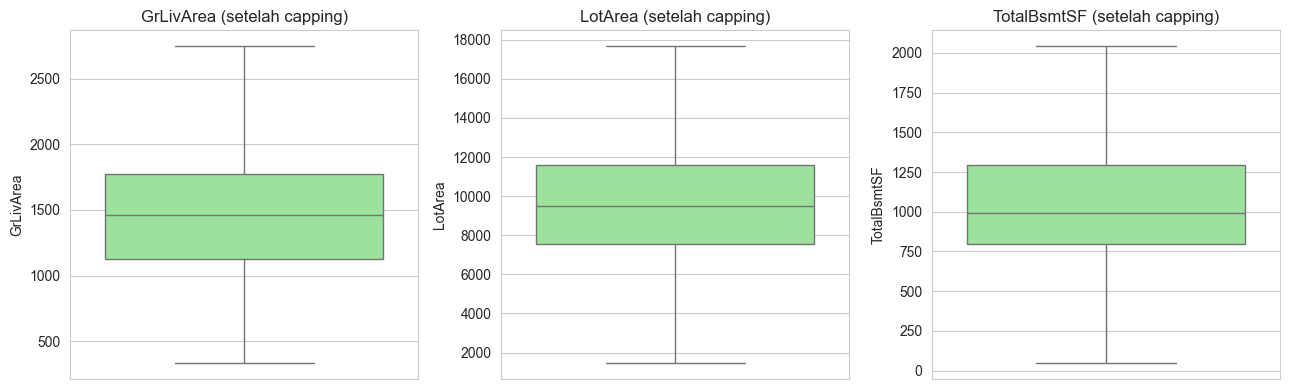

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ['GrLivArea', 'LotArea', 'TotalBsmtSF']):
    sns.boxplot(y=df[col], ax=ax, color='lightgreen')
    ax.set_title(f'{col} (setelah capping)')
plt.tight_layout()
plt.show()


## 9. Encoding Data Kategorikal

Terdapat dua jenis variabel kategorikal pada dataset ini:

1. **Kategorikal ordinal (bertingkat)** — kolom kualitas yang punya urutan makna jelas (`Ex` > `Gd` > `TA` > `Fa` > `Po`), di-*encode* menjadi angka 0–5 agar urutannya tetap bermakna secara numerik.
2. **Kategorikal nominal (tanpa urutan)** — kolom seperti `Neighborhood`, `MSZoning`, `SaleType`, dll, di-*encode* menggunakan **One-Hot Encoding** (`pd.get_dummies`) karena tidak memiliki urutan/tingkatan.

In [13]:
# 1. Encoding ordinal untuk kolom kualitas
skala_kualitas = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
kolom_ordinal = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                  'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in kolom_ordinal:
    df[col] = df[col].map(skala_kualitas)

print("Contoh hasil encoding ordinal (KitchenQual):")
print(df['KitchenQual'].value_counts().sort_index())


Contoh hasil encoding ordinal (KitchenQual):
KitchenQual
2     39
3    735
4    586
5     96
Name: count, dtype: int64


In [14]:
# 2. One-Hot Encoding untuk kolom kategorikal nominal (sisa kolom bertipe object)
kolom_nominal = df.select_dtypes(include='object').columns.tolist()
print(f"Jumlah kolom nominal yang di-one-hot-encode: {len(kolom_nominal)}")
print(kolom_nominal)

df = pd.get_dummies(df, columns=kolom_nominal, drop_first=True)
print(f"\nUkuran dataset setelah one-hot encoding: {df.shape}")


Jumlah kolom nominal yang di-one-hot-encode: 33
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

Ukuran dataset setelah one-hot encoding: (1456, 230)


C:\Users\fauza\AppData\Local\Temp\ipykernel_26640\2017345702.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  kolom_nominal = df.select_dtypes(include='object').columns.tolist()


## 10. Normalisasi Data Numerik

Skala nilai antar kolom numerik sangat berbeda jauh (mis. `LotArea` bisa ribuan, sedangkan `OverallQual` hanya 1–10). Untuk menghindari fitur berskala besar mendominasi analisis/model, seluruh kolom fitur numerik dinormalisasi ke rentang **[0, 1]** menggunakan **Min-Max Scaling**.

Kolom `Id` (hanya identifier, bukan fitur) dan `SalePrice` (variabel target) **tidak** ikut dinormalisasi.

In [15]:
kolom_fitur = [c for c in df.columns if c not in ['Id', 'SalePrice']]

scaler = MinMaxScaler()
df[kolom_fitur] = scaler.fit_transform(df[kolom_fitur])

df[kolom_fitur].describe().loc[['min', 'max']]


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0


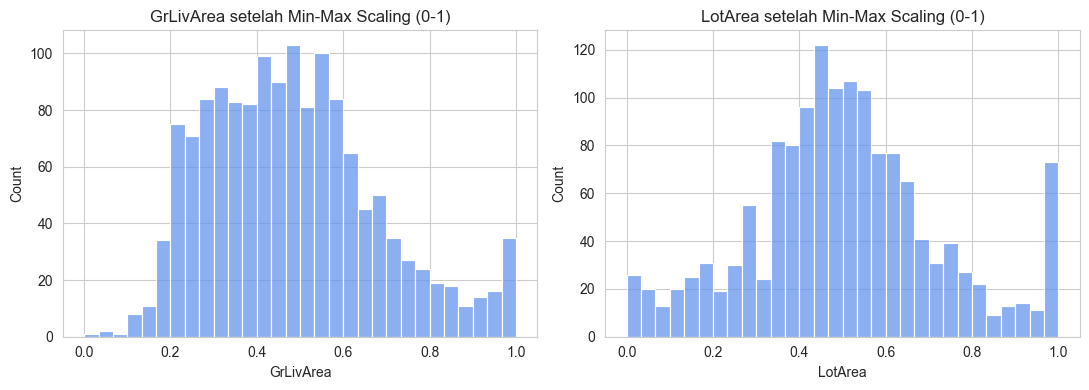

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['GrLivArea'], bins=30, ax=axes[0], color='cornflowerblue')
axes[0].set_title('GrLivArea setelah Min-Max Scaling (0-1)')
sns.histplot(df['LotArea'], bins=30, ax=axes[1], color='cornflowerblue')
axes[1].set_title('LotArea setelah Min-Max Scaling (0-1)')
plt.tight_layout()
plt.show()


## 11. Verifikasi Hasil Akhir Preprocessing

In [17]:
print(f"Ukuran dataset akhir  : {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"Total missing value   : {df.isnull().sum().sum()}")
print(f"Total data duplikat   : {df.duplicated().sum()}")
print(f"Semua kolom numerik?  : {(df.dtypes != 'object').all()}")
df.head()


Ukuran dataset akhir  : 1456 baris, 230 kolom
Total missing value   : 0
Total data duplikat   : 0
Semua kolom numerik?  : True


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,...,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,0.235294,0.4375,0.431260,0.666667,0.500,0.949275,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2,0.000000,0.6250,0.502261,0.555556,0.875,0.753623,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,3,0.235294,0.4750,0.604132,0.666667,0.500,0.934783,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,4,0.294118,0.3750,0.499174,0.666667,0.500,0.311594,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,5,0.235294,0.6750,0.789969,0.777778,0.500,0.927536,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 12. Simpan Dataset Hasil Preprocessing
Dataset yang telah bersih, bebas outlier ekstrem, ter-*encode*, dan ternormalisasi disimpan sebagai `train_processed.csv` untuk digunakan pada tahap analisis/pemodelan selanjutnya.

In [18]:
df.to_csv('train_processed.csv', index=False)
print("Dataset hasil preprocessing berhasil disimpan sebagai 'train_processed.csv'")


Dataset hasil preprocessing berhasil disimpan sebagai 'train_processed.csv'


## 13. Kesimpulan

Tahapan preprocessing yang telah dilakukan terhadap dataset House Prices (`train.csv`):

1. **Missing value** ditangani dengan strategi berbeda sesuai makna kolom: pengisian `'None'`/`0` untuk fitur yang memang tidak ada, median per kelompok untuk `LotFrontage`, dan modus untuk `Electrical`. Hasil akhir: **0 missing value**.
2. **Data duplikat**: tidak ditemukan baris duplikat pada dataset ini.
3. **Outlier** ditangani dengan menghapus anomali terdokumentasi (`GrLivArea > 4000`) dan melakukan *capping* IQR pada kolom numerik kontinu lainnya, sehingga nilai ekstrem tidak lagi mendominasi tanpa kehilangan banyak data.
4. **Transformasi data**: kolom kategorikal ordinal (kualitas) di-*encode* menjadi skala 0–5, kolom kategorikal nominal di-*One-Hot Encoding*, dan seluruh kolom fitur numerik dinormalisasi ke rentang [0, 1] dengan Min-Max Scaling.

Dataset akhir (`train_processed.csv`) sudah bersih, konsisten, dan siap digunakan untuk tahap analisis data atau pemodelan *machine learning* selanjutnya.